# 01 — Exploratory Data Analysis: Brain Tumour MRI

**Task:** 4-class classification of brain MRI slices — `glioma`, `meningioma`, `notumor`, `pituitary`.

**Dataset:** *Brain Tumor MRI Dataset* by Masoud Nickparvar, Kaggle —
https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset — licence **CC BY 4.0**.
It combines three public sources (figshare, SARTAJ and Br35H) and comes already split into
`Training/` and `Testing/` folders, one sub-folder per class. Each sample is a single 2-D MRI slice
stored as a JPEG; the label is the folder name.

**Version note:** the release used here contains **7,200 images** (files dated 2026-02-13), balanced at
1,400 Training and 400 Testing images per class. The 7,023-image figure quoted in papers and in older
descriptions of this dataset refers to an earlier, unbalanced release — cite the version you downloaded.

**Rule used throughout this notebook:** anything that could influence a preprocessing decision
(sample images, sizes, intensities, channel statistics) is measured on the **Training split only**.
The Testing split is only counted and checked for duplicates, so it stays unseen until final evaluation.

**How to run:** run the setup cells below once, then *Imports* and *Config*.
Every section after *Config* depends only on those two cells, so sections can be re-run on their own.

## 0. Setup — download the dataset

Needs `kaggle.json` uploaded to `/content/`. Run these three cells once per Colab session.

In [1]:
#Install Kaggle CLI
!pip install -q kaggle

In [2]:
# 2. Trigger the download
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset

Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 157M/157M [00:00<00:00, 212MB/s]  



In [3]:
# 3. Unzip the images (-n: never overwrite, so re-running this cell doesn't hang on a prompt)
!unzip -qn brain-tumor-mri-dataset.zip -d brain_tumor_data

## 1. Imports

In [4]:
# The libraries this notebook uses:
#   random     - pick random sample images
#   hashlib    - make a "fingerprint" of each file, to find duplicates (Section 10)
#   Path       - build file and folder paths
#   numpy      - treat an image as a grid of numbers
#   matplotlib - draw the charts
#   seaborn    - nicer default chart style
#   Image      - open image files
# No torch here: EDA only looks at the raw image files.
import random
import hashlib
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

## 2. Config

Settings used by every section: where the data is, the class names, the random seed, the colours,
and two small helper functions. Run this cell before any section below.

In [5]:
# Where the unzip cell put the dataset
DATA_ROOT = Path("/content/brain_tumor_data")

# The four class folders, and the two split folders
CLASSES = ["glioma", "meningioma", "notumor", "pituitary"]
SPLITS = ["Training", "Testing"]

# Seed for the random module. Using the same seed every time means
# re-running a cell picks exactly the same random images.
SEED = 42

# One colour per class, so each class looks the same in every chart
CLASS_COLORS = {
    "glioma": "#2a78d6",
    "meningioma": "#eb6834",
    "notumor": "#1baf7a",
    "pituitary": "#4a3aa7",
}

# Seaborn's clean chart style: white background with light grid lines
sns.set_theme(style="whitegrid")


def list_images(split, cls):
    """Return all .jpg files in one folder, e.g. list_images("Training", "glioma")."""
    folder = DATA_ROOT / split / cls
    # sorted() gives the same order on every computer, so the random picks are repeatable
    return sorted(folder.glob("*.jpg"))


def count_images(split):
    """Return how many images each class has in one split, in the same order as CLASSES."""
    counts = []
    for cls in CLASSES:
        counts.append(len(list_images(split, cls)))
    return counts


print("Dataset folder:", DATA_ROOT)

Dataset folder: /content/brain_tumor_data


## 3. Dataset verification

Checks that all eight folders (4 classes × 2 splits) exist and contain images, then prints how many
images each one has. If a folder is missing or empty, the cell stops with a clear message.

In [6]:
# Step 1: check every folder. Stop immediately if one is missing or empty,
# because every later section needs the complete dataset.
for split in SPLITS:
    for cls in CLASSES:
        folder = DATA_ROOT / split / cls
        if not folder.is_dir():
            raise FileNotFoundError(f"Missing folder: {folder}")
        if len(list_images(split, cls)) == 0:
            raise ValueError(f"No .jpg images in: {folder}")

print("All 8 folders exist and contain images.")
print()

# Step 2: count the images and print a table.
# In the f-strings below, :<12 means "left-align in 12 characters" and
# :>10 means "right-align in 10 characters". That keeps the columns lined up.
train_counts = count_images("Training")
test_counts = count_images("Testing")

print(f"{'Class':<12}{'Training':>10}{'Testing':>10}{'Total':>10}")
for i in range(len(CLASSES)):
    total = train_counts[i] + test_counts[i]
    print(f"{CLASSES[i]:<12}{train_counts[i]:>10}{test_counts[i]:>10}{total:>10}")

train_total = sum(train_counts)
test_total = sum(test_counts)
print(f"{'Total':<12}{train_total:>10}{test_total:>10}{train_total + test_total:>10}")

All 8 folders exist and contain images.

Class         Training   Testing     Total
glioma            1400       400      1800
meningioma        1400       400      1800
notumor           1400       400      1800
pituitary         1400       400      1800
Total             5600      1600      7200


## 4. Class distribution

The counts from Section 3 as a bar chart, with Training and Testing side by side for each class.

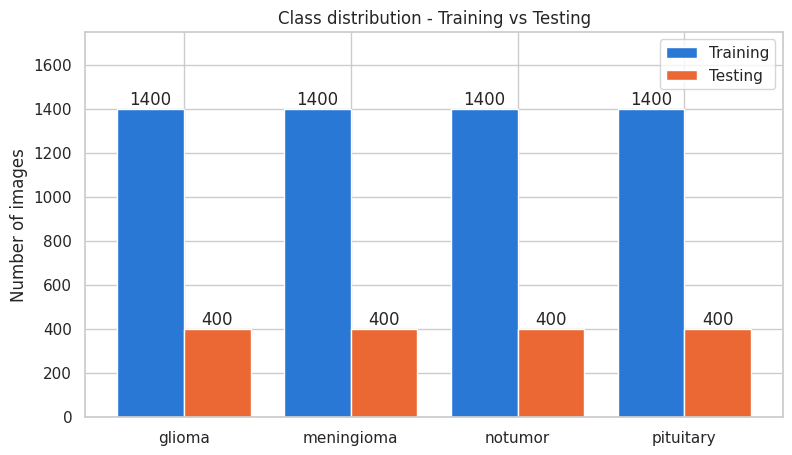

In [7]:
# A grouped bar chart: two bars per class, one for Training and one for Testing.
train_counts = count_images("Training")
test_counts = count_images("Testing")

# One position on the x-axis per class: [0, 1, 2, 3]
x = np.arange(len(CLASSES))

plt.figure(figsize=(9, 5))

# Move the Training bars 0.2 to the left and the Testing bars 0.2 to the right,
# so the two bars for each class sit next to each other instead of on top of each other
train_bars = plt.bar(x - 0.2, train_counts, width=0.4, label="Training", color="#2a78d6")
test_bars = plt.bar(x + 0.2, test_counts, width=0.4, label="Testing", color="#eb6834")

# Write the number on top of each bar
plt.bar_label(train_bars)
plt.bar_label(test_bars)

plt.xticks(x, CLASSES)  # class names under the bars
plt.ylim(0, max(train_counts) * 1.25)  # empty space above the bars, so the legend doesn't cover them
plt.ylabel("Number of images")
plt.title("Class distribution - Training vs Testing")
plt.legend()
plt.show()

## 5. Class imbalance analysis

Imbalance ratio = number of images in the largest class ÷ number in the smallest class.
Rule of thumb used here: **1.0 = perfectly balanced**, **< 1.5 mild**, **1.5–3 moderate**, **> 3 severe**.

The *baseline accuracy* is what you would score by always guessing the largest class.
Any real model has to beat it.

In [8]:
# For each split, compare the largest class with the smallest class.
for split in SPLITS:
    counts = count_images(split)
    largest = max(counts)
    smallest = min(counts)
    ratio = largest / smallest

    # Decide how serious the imbalance is, using the rule of thumb above
    if ratio == 1:
        verdict = "PERFECTLY BALANCED - every class has the same number of images"
    elif ratio < 1.5:
        verdict = "MILD - no resampling needed"
    elif ratio <= 3:
        verdict = "MODERATE - consider class weights or oversampling"
    else:
        verdict = "SEVERE - resampling or class weights required"

    baseline_accuracy = largest / sum(counts) * 100

    print(split)
    print("  largest class :", largest, "images")
    print("  smallest class:", smallest, "images")
    print("  imbalance ratio:", round(ratio, 2), "->", verdict)
    print("  always guessing the largest class gives", round(baseline_accuracy, 1), "% accuracy")
    print()

Training
  largest class : 1400 images
  smallest class: 1400 images
  imbalance ratio: 1.0 -> PERFECTLY BALANCED - every class has the same number of images
  always guessing the largest class gives 25.0 % accuracy

Testing
  largest class : 400 images
  smallest class: 400 images
  imbalance ratio: 1.0 -> PERFECTLY BALANCED - every class has the same number of images
  always guessing the largest class gives 25.0 % accuracy



## 6. Sample images

Five random Training images per class, one row per class. Each image's title is its original size.

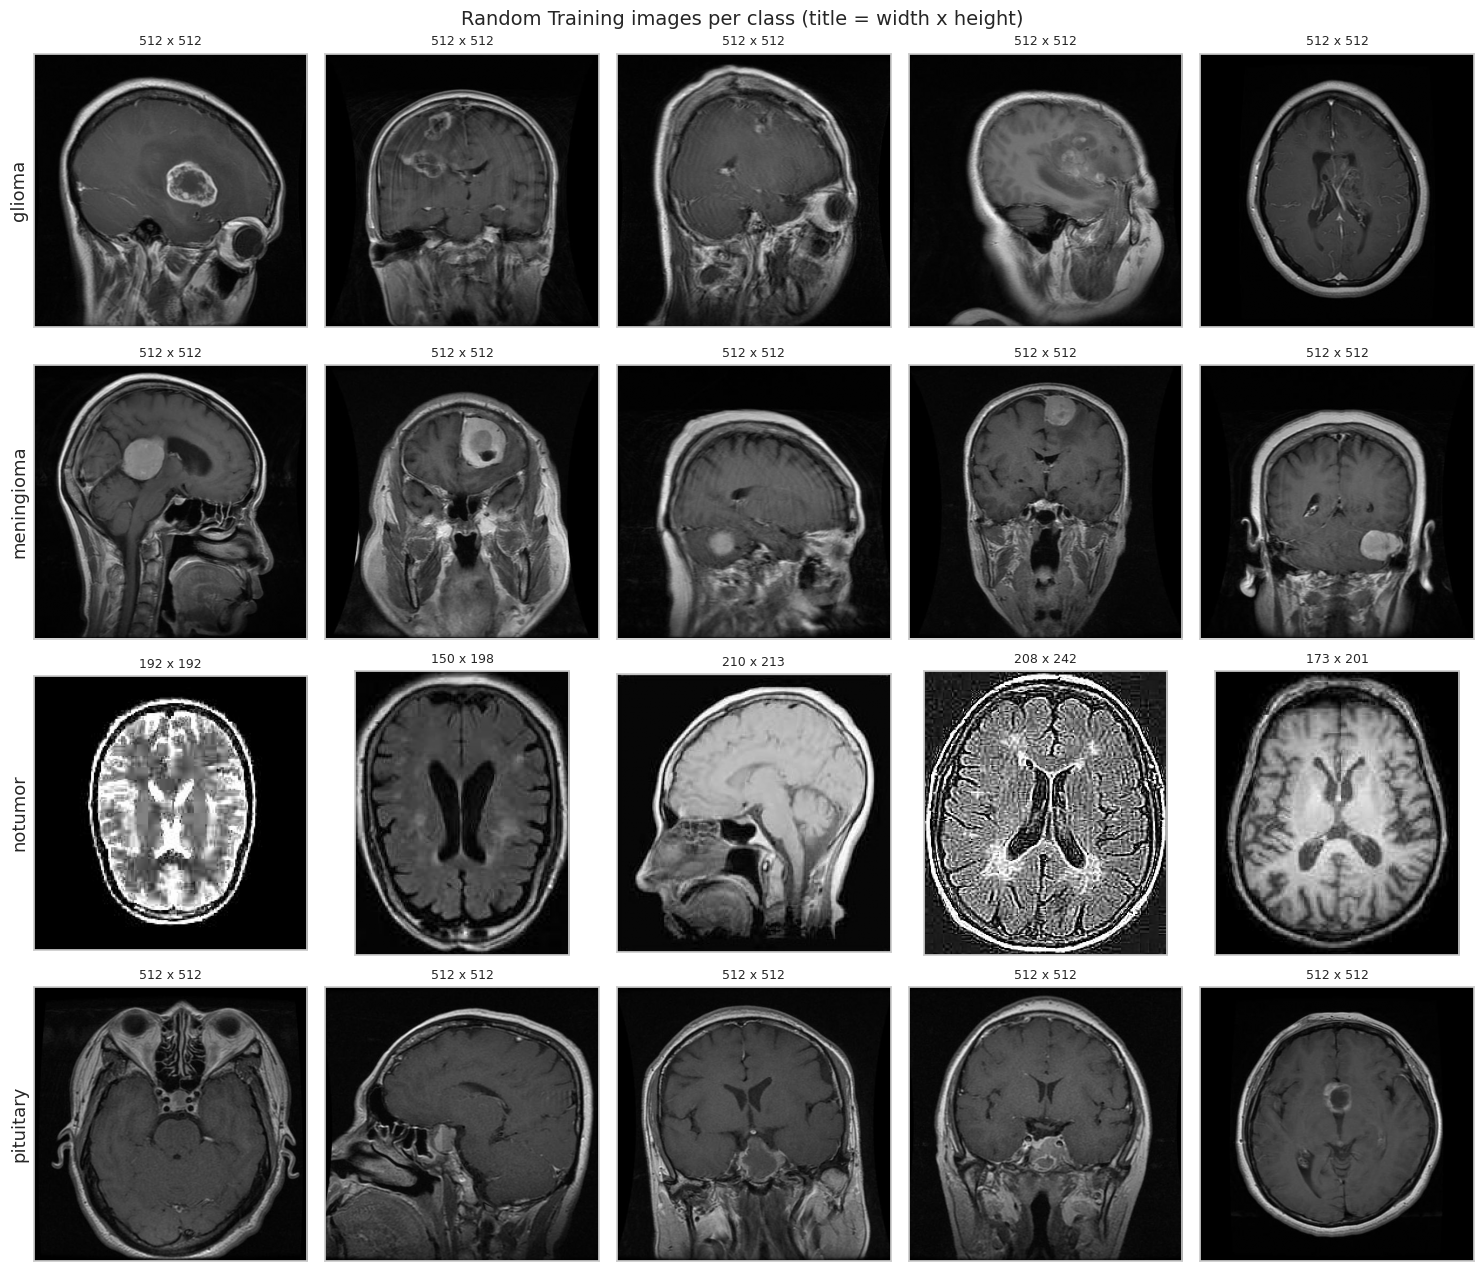

In [9]:
# Look at real examples: do the images match their labels, and how different
# do the four classes look? MRI scans are grayscale, so we show them in gray.
random.seed(SEED)

# A grid of 4 rows (one per class) x 5 columns (five images)
fig, axes = plt.subplots(4, 5, figsize=(15, 13))

for row in range(len(CLASSES)):
    cls = CLASSES[row]
    # random.sample picks 5 different images from the list
    paths = random.sample(list_images("Training", cls), 5)

    for col in range(5):
        img = Image.open(paths[col])
        ax = axes[row, col]  # the small plot at this row and column
        ax.imshow(img.convert("L"), cmap="gray")  # "L" means grayscale
        ax.set_title(f"{img.width} x {img.height}", fontsize=9)
        ax.set_xticks([])  # hide the pixel numbers along the edges
        ax.set_yticks([])

    axes[row, 0].set_ylabel(cls, fontsize=13)  # class name at the start of the row

plt.suptitle("Random Training images per class (title = width x height)", fontsize=14)
plt.tight_layout()  # remove extra white space between the images
plt.show()

## 7. Image size verification

Opens 10 random Training images per class and records their `(width, height)`.
A CNN needs every input to have the same size, so if the sizes differ, resizing is required.

In [10]:
# Collect the sizes of 10 random images per class.
# A set only keeps unique values, so each size is stored once.
random.seed(SEED)

all_sizes = set()

for cls in CLASSES:
    class_sizes = set()
    paths = random.sample(list_images("Training", cls), 10)
    for path in paths:
        img = Image.open(path)
        class_sizes.add(img.size)  # img.size is (width, height)
        all_sizes.add(img.size)
    print(cls, "->", sorted(class_sizes))

print()
print("Different sizes found:", len(all_sizes))
if len(all_sizes) > 1:
    print("WARNING: the images are not all the same size, so every image must be")
    print("resized to one size (224 x 224 in src/transforms.py) before training.")
else:
    print("All sampled images have the same size.")

glioma -> [(512, 512)]
meningioma -> [(318, 354), (416, 395), (512, 512)]
notumor -> [(173, 201), (218, 231), (225, 225), (227, 222), (230, 282), (235, 227), (236, 213), (236, 236), (420, 280), (630, 630)]
pituitary -> [(512, 512), (1335, 1302)]

Different sizes found: 14
resized to one size (224 x 224 in src/transforms.py) before training.


## 8. Pixel intensity distribution

For 50 random Training images per class, every pixel's brightness (0 = black, 255 = white) goes into
a histogram. One line per class, all on the same chart.

- `density=True` shows the *fraction* of pixels instead of the raw count, so classes are compared fairly.
- The y-axis is logarithmic because MRI images contain far more black background pixels than tissue
  pixels. On a normal axis, the background spike would flatten everything else.

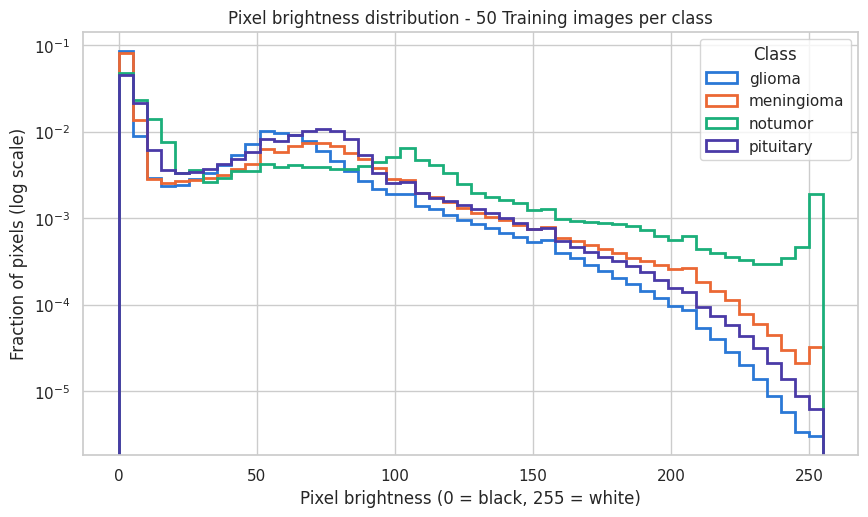

In [11]:
# Build one brightness histogram per class and draw them on the same chart.
random.seed(SEED)

plt.figure(figsize=(10, 5.5))

for cls in CLASSES:
    pixel_arrays = []
    paths = random.sample(list_images("Training", cls), 50)
    for path in paths:
        gray = Image.open(path).convert("L")  # "L" means grayscale
        pixels = np.array(gray).flatten()  # turn the 2-D image into one long row of numbers
        pixel_arrays.append(pixels)

    # Join the 50 rows into one long row, so the whole class is one histogram
    all_pixels = np.concatenate(pixel_arrays)

    # histtype="step" draws only the outline, so the four lines don't hide each other
    plt.hist(all_pixels, bins=50, density=True, histtype="step", linewidth=2,
             label=cls, color=CLASS_COLORS[cls])

plt.yscale("log")
plt.xlabel("Pixel brightness (0 = black, 255 = white)")
plt.ylabel("Fraction of pixels (log scale)")
plt.title("Pixel brightness distribution - 50 Training images per class")
plt.legend(title="Class")
plt.show()

## 9. RGB channel means

The average Red, Green and Blue value of 50 random Training images per class.
MRI scans have only one channel. If the files are grayscale images saved in colour format,
R, G and B will be exactly the same.

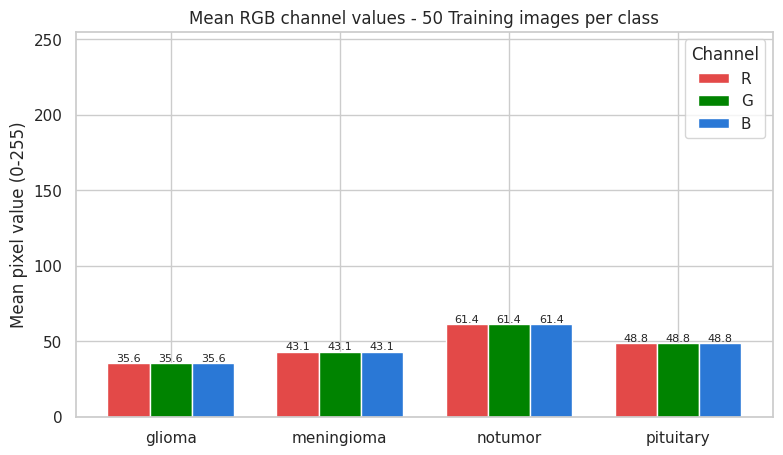

glioma -> R: 35.61  G: 35.61  B: 35.61
meningioma -> R: 43.09  G: 43.09  B: 43.09
notumor -> R: 61.38  G: 61.37  B: 61.4
pituitary -> R: 48.82  G: 48.82  B: 48.82


In [12]:
# Measure the average Red, Green and Blue value of each class.
random.seed(SEED)

red_means = []
green_means = []
blue_means = []

for cls in CLASSES:
    red_values = []
    green_values = []
    blue_values = []

    paths = random.sample(list_images("Training", cls), 50)
    for path in paths:
        rgb = np.array(Image.open(path).convert("RGB"))  # shape: (height, width, 3)
        # rgb[:, :, 0] means "every row, every column, channel 0" - the red channel
        red_values.append(rgb[:, :, 0].mean())
        green_values.append(rgb[:, :, 1].mean())
        blue_values.append(rgb[:, :, 2].mean())

    # Average over the 50 images of this class
    red_means.append(np.mean(red_values))
    green_means.append(np.mean(green_values))
    blue_means.append(np.mean(blue_values))

# Grouped bar chart: three bars (R, G, B) per class
x = np.arange(len(CLASSES))  # [0, 1, 2, 3]

plt.figure(figsize=(9, 5))
red_bars = plt.bar(x - 0.25, red_means, width=0.25, label="R", color="#e34948")
green_bars = plt.bar(x, green_means, width=0.25, label="G", color="#008300")
blue_bars = plt.bar(x + 0.25, blue_means, width=0.25, label="B", color="#2a78d6")

# Write the value on top of each bar, with one decimal place ("%.1f")
plt.bar_label(red_bars, fmt="%.1f", fontsize=8)
plt.bar_label(green_bars, fmt="%.1f", fontsize=8)
plt.bar_label(blue_bars, fmt="%.1f", fontsize=8)

plt.xticks(x, CLASSES)
plt.ylim(0, 255)  # show the full range of possible pixel values
plt.ylabel("Mean pixel value (0-255)")
plt.title("Mean RGB channel values - 50 Training images per class")
plt.legend(title="Channel")
plt.show()

# The same numbers as text. Equal R, G and B means the image is really grayscale.
for i in range(len(CLASSES)):
    print(CLASSES[i], "-> R:", round(red_means[i], 2),
          " G:", round(green_means[i], 2),
          " B:", round(blue_means[i], 2))

## 10. Duplicate & leakage check

An **MD5 hash** is a short "fingerprint" computed from a file's contents. Two files with exactly the same
content always get the same fingerprint, so files that share a fingerprint are duplicates.

Where a duplicate sits decides whether it is a problem:
- **In Training and Testing** — data leakage. The model would be tested on an image it trained on,
  which makes the test score look better than it really is.
- **Inside Training** — copies can end up on both sides of the train/validation split, which makes
  the validation score look better than it really is.
- **Inside Testing** — some test images count twice in the final score. Not leakage, but worth noting.
- **Under two different classes** — the same scan has two different labels, which is a labelling error.

Only byte-for-byte identical copies are found. A copy that was re-saved or resized has a different fingerprint.

In [13]:
# Step 1: compute the fingerprint of every image file.
# hash_to_files maps each fingerprint to the list of files that have it.
hash_to_files = {}
total_files = 0

for split in SPLITS:
    for cls in CLASSES:
        for path in list_images(split, cls):
            fingerprint = hashlib.md5(path.read_bytes()).hexdigest()
            short_path = path.relative_to(DATA_ROOT)  # e.g. Training/glioma/Tr-gl_1.jpg

            if fingerprint not in hash_to_files:
                hash_to_files[fingerprint] = []
            hash_to_files[fingerprint].append(short_path)
            total_files += 1

# Step 2: look at every fingerprint that belongs to more than one file.
duplicate_groups = 0
redundant_copies = 0
train_test_overlap = 0
inside_training = 0
inside_testing = 0
label_conflicts = []

for files in hash_to_files.values():
    if len(files) == 1:
        continue  # only one file has this fingerprint, so it is not a duplicate

    duplicate_groups += 1
    redundant_copies += len(files) - 1  # every copy after the first one is extra

    # Which splits and which classes do the copies come from?
    # .parts splits a path into pieces: ("Training", "glioma", "Tr-gl_1.jpg")
    splits_in_group = set()
    classes_in_group = set()
    for short_path in files:
        splits_in_group.add(short_path.parts[0])
        classes_in_group.add(short_path.parts[1])

    if len(splits_in_group) == 2:
        train_test_overlap += 1
    elif "Training" in splits_in_group:
        inside_training += 1
    else:
        inside_testing += 1

    if len(classes_in_group) > 1:
        label_conflicts.append(files)

# Step 3: print the results.
print("Images checked:          ", total_files)
print("Unique images:           ", len(hash_to_files))
print("Duplicate groups:        ", duplicate_groups)
print("Redundant copies:        ", redundant_copies)
print("  in Training AND Testing:", train_test_overlap)
print("  inside Training only:   ", inside_training)
print("  inside Testing only:    ", inside_testing)
print("  same image, 2 classes:  ", len(label_conflicts))

# Show up to 5 label conflicts (the same image saved under two class folders)
for files in label_conflicts[:5]:
    print()
    for short_path in files:
        print("   ", short_path)

Images checked:           7200
Unique images:            7013
Duplicate groups:         153
Redundant copies:         187
  in Training AND Testing: 0
  inside Training only:    138
  inside Testing only:     15
  same image, 2 classes:   0


## 11. EDA summary

> Counts measured with Section 3 on the release downloaded for this project (files dated 2026-02-13).
> If Section 3 prints different numbers, the dataset version has changed — update this table.

| | glioma | meningioma | notumor | pituitary | **Total** |
|---|---:|---:|---:|---:|---:|
| Training | 1,400 | 1,400 | 1,400 | 1,400 | **5,600** |
| Testing | 400 | 400 | 400 | 400 | **1,600** |
| **Total** | 1,800 | 1,800 | 1,800 | 1,800 | **7,200** |

**Key findings**

1. **Size.** 7,200 images in total: 5,600 Training and 1,600 Testing, a 77.8% / 22.2% split supplied by
   the dataset author.
2. **Class balance.** Every class holds exactly 1,400 Training and 400 Testing images, so the imbalance
   ratio is **1.00 — perfectly balanced**. Accuracy is therefore directly interpretable, and both the
   random and the majority-class baseline sit at 25%. The balance is a property of how this release was
   assembled, not the real-world prevalence of these tumour types, which is worth stating in the report.
3. **Image size.** The images do not share one resolution (Section 7; the dataset author states this too),
   so there is no native input size to preserve.
4. **Channels.** R, G and B are identical (Section 9): these are grayscale scans saved as 3-channel JPEGs,
   so colour carries no class information.
5. **Intensity.** Every class is dominated by black background, and the four brightness curves largely
   overlap (Section 8). The classes are not separable by overall image brightness — the signal is local
   (tumour location, shape, texture), which is what a CNN is able to learn.
6. **Duplicates.** 7,200 files contain 7,013 unique images: 153 groups of exact duplicates, 187 redundant
   copies (2.6%). **None** is shared between Training and Testing, so the test set is free of exact-copy
   leakage. Section 10 shows how the rest split between Training, Testing and two-class label conflicts.

**What this means for preprocessing**

- **Resize every image to 224×224** (already in `src/transforms.py`), because the sizes vary and all four
  pretrained backbones expect 224×224.
- **Keep 3 channels** by replicating the grayscale channel, so ImageNet-pretrained models accept the input,
  and **normalise with ImageNet mean/std** to match how those models were trained.
- **No resampling and no class weighting** — the classes are already balanced. Still use a **stratified**
  train/validation split so the 25/25/25/25 mix survives the split, and still report **macro-F1 and
  per-class recall** next to accuracy, because balance does not stop a model failing on one class.
- **Augmentation:** flips, small rotations and brightness/contrast jitter are reasonable; hue/saturation
  jitter is not, because there is no colour.
- **Duplicates:** remove the copies inside Training *before* the train/validation split, so no image sits on
  both sides of it. Any image labelled with two classes should be dropped. The Testing split stays untouched.
- Every statistic above was measured on the **Training split only**.